## [미션 5]  미션 설명
이번 미션에서는 손상된 문서를 복원하는 작업을 수행합니다. 오토인코더를 활용하여 문서 이미지의 품질을 향상시키고, 문서의 내용을 최대한 복원하는 모델을 구현해 봅시다. 문서는 습기, 찢김, 얼룩 등 다양한 이유로 손상될 수 있는데요. 이번 미션의 목표는 손상된 문서에서 노이즈를 제거하여 원본 문서를 최대한 복원하는 것입니다. 아래 데이터셋을 활용하여 다양한 복원 기법을 실험해보고, 성능을 평가해 보세요.

### 데이터 소개
- train: 손상된 문서(모델 훈련용)
- train_cleaned: 손상된 문서의 원본(모델 훈련용)
- test: 손상된 문서(모델 테스트용)


### 가이드라인
- 데이터 로드 및 전처리
    - 손상 이미지(train)와 원본 이미지(train_cleaned)를 짝지어 불러오고, 모델에 입력할 텐서로 변환하세요.
    - 이미지 크기가 두 종류(420×540, 258×540)라는 점에 유의하세요. 
    - 크기를 통일하거나, 일정 크기로 잘라서(crop) 학습하는 방법 중 선택할 수 있습니다.
- 모델 설계
    - Conv2d로 인코더를, ConvTranspose2d로 디코더를 구성한 CNN 오토인코더를 설계하세요.
    - 층을 지날 때마다 텐서 크기가 어떻게 변하는지 주석으로 남기며 설계해 보세요. 인코더와 디코더의 크기가 어긋나는 문제는 이 미션에서 가장 자주 만나는 에러입니다.
- 모델 학습
    - 손실 함수와 옵티마이저를 선택하고, 선택한 이유를 기록하세요.
- 모델 평가
    - 평가 지표(RMSE, PSNR 등)로 복원 품질을 평가하세요.
    - 손상/복원/원본 이미지를 나란히 시각화해서, 모델이 어떤 노이즈를 잘 지우고 어떤 노이즈를 남기는지 확인해 보세요.
- 모델 성늘 개선
    - 네트워크 깊이와 채널 수 조정, 데이터 증강, 스킵 커넥션 추가 등을 실험하며 복원 품질을 높여 보세요.
    

## 1-1. 데이터 준비 

In [7]:
!kaggle auth login 


You are already logged-in to Kaggle as [doosungbang].
Please use the --force flag to override.


In [9]:
import kagglehub

In [ ]:
!kaggle competitions list

ref                                                                           deadline             category         reward  teamCount  userHasEntered  userRank  
----------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  --------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge   2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False         0  
https://www.kaggle.com/competitions/zillow-prize-1                            2018-01-10 15:59:00  Featured  1,200,000 Usd       3770           False         0  
https://www.kaggle.com/competitions/data-science-bowl-2017                    2017-04-12 23:59:00  Featured  1,000,000 Usd       1972           False         0  
https://www.kaggle.com/competitions/vesuvius-challenge-ink-detection          2023-06-14 23:59:00  Featured  1,000,000 Usd       1249           False         0  
https://www.kaggle.com/compe

In [13]:
# Download latest version
path = kagglehub.competition_download('denoising-dirty-documents')

print("Path to competition files:", path)

100%|██████████| 35.7M/35.7M [00:01<00:00, 21.9MB/s]

Extracting files...


Path to competition files: C:\Users\dsbang\.cache\kagglehub\competitions\denoising-dirty-documents


In [3]:
%pip install unzip

  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for unzip: filename=unzip-1.0.0-py3-none-any.whl size=1311 sha256=678257ac0bdf284f6327364e36b15c8e05518827f680367ad7c2705f0397d257
  Stored in directory: c:\users\dsbang\appdata\local\pip\cache\wheels\e2\c2\a1\49741989a90949e9478d5f005545362d10354e2e850996cf62
Successfully built unzip
Note: you may need to restart the kernel to use updated packages.


In [7]:
path = 'C:/Users/dsbang/.cache/kagglehub/competitions/denoising-dirty-documents'
#!mkdir -p 'data/denoising-dirty-doc' #윈도우에서 에러 발생

In [ ]:
## 타켓 폴더가 없으면 생성
!unzip -o -q {path}/train.zip -d data/denoising-dirty-doc
!unzip -o -q {path}/test.zip -d data/denoising-dirty-doc
!unzip -o -q {path}/train_cleaned.zip -d data/denoising-dirty-doc


In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
print("PyTorch:", torch.__version__, "| device:" , device) 


PyTorch: 2.14.0+cpu | device: cpu


## 1-2. Dataset 구성

이미지 크기가 두 종류(420×540, 258×540)라서, 학습할 때는 **같은 위치에서 128×128 패치를 잘라** 손상/원본 쌍으로 사용

In [ ]:
import os
import random
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import torchvision.transforms.functional as TF


# Dataset() : 데이터를 가져오고 정제하는 파이프라인의 시작점
# 전체 데이터셋을 하나의 거대한 덩어리로 관리하는 대신, 
# 이터의 총개수를 파악하고 요청받은 인덱스(idx)에 데이터 한 장을 반환하는 역할

class DirtyDocsDataset(Dataset):
    """손상 이미지와 원본 이미지에서 같은 위치의 패치를 한 쌍으로 돌려줍니다"""

    def __init__(self, dirty_dir, clean_dir, crop_size=128, files=None, train=True):
        # 1. 초기화: 데이터 경로 지정, 파일 리스트 읽기, 전처리 정의
        self.dirty_dir = dirty_dir
        self.clean_dir = clean_dir
        self.crop_size = crop_size
        self.train = train
        #self.files = sorted( os.listdir(dirty_dir))
        #지정된 디렉토리에서 .png 확장자로 끝나는 이미지 파일들을 정렬하여 리스트로 가져오는 코드
        self.files = files if files is not None else sorted(         ##
            f for f in os.listdir(dirty_dir) if f.endswith(".png")  ##
        )

        # # 이미지 크롭을 중앙에서만 할 때 및 텐서 변환 정의
        # self.transform = transforms.Compose([
        #     transforms.CenterCrop(crop_size),
        #     transforms.ToTensor()
        # ])

    def __len__(self):
        # 2. 데이터셋의 총 데이터(샘플) 개수를 반환
        return len(self.files)

    def __getitem__(self, idx): 
        # 3. 지정된 인덱스(idx)에 해당하는 데이터 한 장을 읽어서 반환
        # 보통 (입력 데이터, 정답 레이블)을 튜플 형태로 반환합니다.

        # 3.1. 파일 이름 가져오기
        name = self.files[idx] 
        # 3.2. 동일한 파일 이름을 가진 dirty 이미지와 clean 이미지의 절대 경로 생성
        dirty = Image.open(os.path.join(self.dirty_dir, name)).convert("L")
        clean = Image.open(os.path.join(self.clean_dir, name)).convert("L")

        # random 으로 좌표를 지정하여 - 데이터 증강 효과
        cs = self.crop_size
        if self.train:  # 학습: 랜덤 위치
            heigh = random.randint(0, dirty.height - cs)
            width = random.randint(0, dirty.width - cs)
        else:           # 검증: 항상 중앙 (매번 같은 조건)
            heigh = (dirty.height - cs) // 2
            width = (dirty.width - cs) // 2
            # --참고. 동일한 변형(Crop) 항상 중앙 위치 적용
            #dirty = self.transform(dirty)
            #clean = self.transform(clean)            

        # 4. 동일한 변형(Crop) 랜덤하게 위치 적용
        dirty = TF.to_tensor(TF.crop(dirty, heigh, width, cs, cs))
        clean = TF.to_tensor(TF.crop(clean, heigh, width, cs, cs)) 

        return dirty, clean 

## 학습/검증 데이터 분리
dirty_dir='data/denoising-dirty-doc/train'
clean_dir='data/denoising-dirty-doc/train_cleaned'

all_files = sorted(f for f in os.listdir(dirty_dir) if f.endswith(".png"))

random.seed(42)     # 항상 같은 분할이 되도록 고정
random.shuffle(all_files) # 파일 섞기 

n_val = 16          # 144장 중 16장을 검증용으로
val_files, train_files = all_files[:n_val], all_files[n_val:]   #128장 / 16장 분리

train_dataset = DirtyDocsDataset(dirty_dir, clean_dir, files=train_files, train=True)
val_dataset   = DirtyDocsDataset(dirty_dir, clean_dir, files=val_files,   train=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=16, shuffle=False)

# train_dataset = DirtyDocsDataset(dirty_dir=dirty_dir ,clean_dir=clean_dir)
# train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, drop_last=False)
print("학습 이미지 수:", len(train_dataset), ", 16개의 이미지는 갖는 배치 숫자:", len(train_loader))


학습 이미지 수: 128 , 16개의 이미지는 갖는 배치 숫자: 8


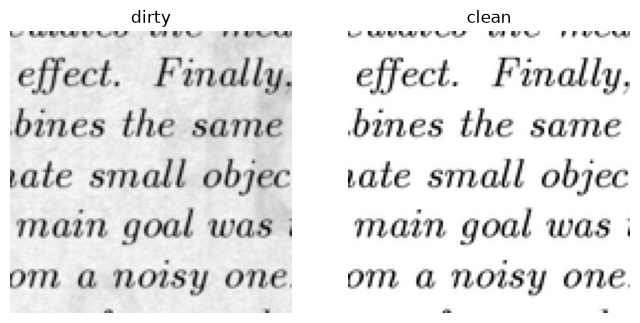

In [39]:
# 손상/원본 쌍이 잘 만들어졌는지 확인
dirty, clean = train_dataset[0]

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].imshow(dirty.squeeze(), cmap='gray');    axes[0].set_title('dirty')
axes[1].imshow(clean.squeeze(), cmap='gray');    axes[1].set_title('clean')
for ax in axes: ax.axis('off')
plt.show()


In [ ]:
#마지막 함수결정을 위해 정답(타깃) 데이터의 값 범위와 성격 확인
# .item()은 텐서를 파이썬 숫자로 꺼내주는 함수
dirty, clean = next(iter(train_loader))   
print('정답 이미지의 최소값:', clean.min().item(), ', 이미지의 최대값:',clean.max().item())   # 예: 0.0 ~ 1.0
print('정답 이미지의 평균(=배경)값:', clean.mean().item())                       # 배경이 흰색이면 1에 가까움

# 0~1 (정규화된 픽셀, 확률)            : Sigmoid      - 이진 분류
#-1~1 (Normalize(0.5, 0.5)한 이미지)  : Tanh         - GAN 생성기
# 제한 없는 실수                       : 없음 (Linear) - 가격, 온도 등 회귀  
# 여러 클래스 중 하나 0~1 (확율)        : Softmax       - 다중 분류
# 0 이상 값 (개수 등)                  : ReLU 또는 Softplus - 카운트 예측

정답 이미지의 최소값: 0.0 , 이미지의 최대값: 1.0
정답 이미지의 평균(=배경)값: 0.8834792971611023


## 1-3. CNN 오토인코더 설계
`Conv2d`(stride=2)로 크기를 절반씩 줄이며 특징을 압축하고, `ConvTranspose2d`로 다시 원래 크기까지 복원

- 층마다 텐서 크기가 어떻게 변하는지 주석으로 기록
- 인코더와 디코더의 크기가 어긋나는 문제로 에러 발생할 수 있음 .

In [41]:
class ConvDenoiser(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, stride=2, padding=1), 
            #(1, 128, 128) 128로 크롭한 크기  ==> (32, 64, 64) 크기 변환( stride=2 필터를 2칸씩 건너뛰며 적용해서 가로세로를 절반으로 줄입 )
            nn.ReLU(),
            #Conv2d는 입력에 가중치를 곱하고 더하는 선형 연산(층을 쌓아도 결국 하나의 선형 연산)
            #선형적인 패턴을 비선형적인 패턴(글자의 획, 얼룩과 배경의 경계 등의 특징)을 두두러지게 표현하 도록 음수는 0으로 무시하고 양수만 취하도록 처리
            nn.Conv2d(in_channels=32, out_channels=64,kernel_size=3, stride=2, padding=1 ), 
            #(32, 64, 64) 1차 Conv2d의 결과 크기 ==> (64, 32, 32) 크기로 변환 ( stride=2 필터를 2칸씩 건너뛰며 적용해서 가로세로를 절반으로 줄입 )
            #channel수는 깊어질수록 2배씩 늘리는 것이 관행, 채널이 많을수록 더 다양한 특징을 잡을 수 있지만 단점으로 파라미터와 메모리도 늘어남
            #channel수는 은닉층이 출력하는 **특징 맵(feature map)의 개수 / 은닉층: 입력과 출력 사이에 있는 층
            nn.ReLU(),
            #비선형적인 패턴(글자의 획, 얼룩과 배경의 경계 등)을 표현하 도록 음수는 0으로 바꾸고 양수는 그대로 통과
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            #인코더에서 압축된(64, 32, 32) 크기를 (32, 64, 64) 크리로 늘림 (늘림 기능 파라미터는 stride=2)
            #kernel이 stride의 배수(4 = 2×2)라서 겹침이 고르게 분포하여, kernel 3처럼 발생하는 체커보드 무늬를 피할 수 있음
            nn.ReLU(),
            #비선형적인 팬턴 강화
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),
            #첫번째 ConvTranspose2d의 결과(32, 64, 64) 크기를 (1, 128, 128) 크리로 늘림 (늘림 기능 파라미터는 stride=2)
            #kernel의 크기를 stride의 배수(4 = 2×2)로 사용해 부드러운 이미지로 복원 
            nn.Sigmoid(),
            #중간층에는 ReLU를 쓰고(특징을 비선형으로 특징을 걸러냄), 
            #마지막 출력층에는 원하는 출력 범위에 맞는 함수를 씁니다. 
            # 출력이 확률이나 0~1 픽셀이면 Sigmoid, 
            # -1~1이면 Tanh, 
            # 제한이 없는 값이면 활성화 함수를 생략
        )
    def forward(self, x):
        return self.decoder(self.encoder(x))

model = ConvDenoiser().to(device)
print(model)    


ConvDenoiser(
  (encoder): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
    (3): ReLU()
  )
  (decoder): Sequential(
    (0): ConvTranspose2d(64, 32, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): ReLU()
    (2): ConvTranspose2d(32, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (3): Sigmoid()
  )
)


In [ ]:
#순전파 후 오차계산을 평균으로 확인하는 평가 함수
def evaluate(model, loader, criterion, device):
    model.eval()                     # 평가 모드 (Dropout/BatchNorm이 있다면 동작 변경)
    total = 0.0
    with torch.no_grad():            # 기울기 계산 안 함 (메모리/속도 절약)
        for dirty, clean in loader:
            dirty, clean = dirty.to(device), clean.to(device)
            loss = criterion(model(dirty), clean) #순전파 및 오차계산
            total += loss.item() * len(dirty)
    return total / len(loader.dataset)

In [ ]:
## 학습 루프
#오차(손실)계산 함수 지정 - 노이즈 제거는 픽셀마다 정답 값(0~1)이 있는 회귀 문제이고, MSE는 회귀의 기본 손실함수 -오차를 제곱하므로 크게 틀린 픽셀에 더 큰 패널티를 줍니다
criterion = nn.MSELoss()  #MSE(평균제곱오차) 구하는 함수 - 예측과 정답의 차이를 제곱해서 평균 /선명도가 아쉬우면 nn.L1Loss 를 비교 

#옵티마이저 지정 - 손실을 줄이는 방향으로 가중치를 갱신하는 역할
# -- Adam을 쓰는 이유: 기본 SGD와 달리 파라미터마다 학습률을 자동으로 조절하고(적응형), 이전 기울기의 방향을 반영(모멘텀)합니다.
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
# -- model.parameters(): 갱신할 대상(모든 Conv, ConvTranspose의 weight, bias)을 알려줍니다
# -- lr=1e-3 (학습률): 한 번에 가중치를 얼마나 크게 바꿀지를 정합니다

best_val = float("inf") ##

EPOCHS=30 ## 전체 데이터를 30바퀴 학습
for epoch in range(EPOCHS):

    model.train() # 학습 모드
    epoch_loss = 0.0

    for dirty, clean in train_loader:  ## 배치 9개를 차례로 (144÷16)
        # 데이터를 GPU(또는 CPU)로
        dirty, clean = dirty.to(device), clean.to(device)
        #누적된 기울기를 0으로 초기화
        optimizer.zero_grad()
        #순전파: 예측 생성
        restored = model(dirty)
        #예측과 정답의 오차 계산
        loss = criterion(restored, clean)   #참고: loss = criterion(model(dirty), clean)
        #역전파: 각 가중치의 기울기 계산
        loss.backward()
        #기울기를 이용해 가중치(w)를 업데이트
        optimizer.step()

        #손실 모니터용 
        # loss.item()은 텐서를 파이썬 숫자로 꺼냅니다.  * len(dirty) 문서 갯수를 곱해서 총 손실 숫자를 구합니다.
        epoch_loss += loss.item() * len(dirty)

    train_loss = epoch_loss / len(train_dataset) #train_loss는 배치 평균값이므로 * len(dirty)로 배치 내 합계로 되돌리고, 마지막에 전체 데이터 수로 나누기
    val_loss = evaluate(model, val_loader, criterion, device) #에포크마다 val_data로 오차율 평가

    #진행 epoch 5번째 마다 손실(오차) 모니터값 출력
    if (epoch + 1) % 5 == 0: #5, 10, ..., 30번째 에포크에서만 출력
        print(f"Epoch {epoch + 1:3d} | train_loss {train_loss:.5f} | val_loss {val_loss:.5f} "
              f" | val RMSE {val_loss**0.5:.4f}")
        




Epoch   5 | loss 0.06744 | val 0.06536  | val RMSE 0.2557
Epoch  10 | loss 0.02835 | val 0.02639  | val RMSE 0.1625
Epoch  15 | loss 0.01605 | val 0.01577  | val RMSE 0.1256
Epoch  20 | loss 0.01095 | val 0.01063  | val RMSE 0.1031
Epoch  25 | loss 0.00833 | val 0.00821  | val RMSE 0.0906
Epoch  30 | loss 0.00661 | val 0.00681  | val RMSE 0.0825


## 1-4. 전체 이미지 복원과 평가
- 학습은 128×128 조각으로 했지만, 실제로 복원해야 하는 것은 문서 전체 이미지입니다. 
- 이 데이터셋은 이미지 크기가 258×540, 420×540 두 종류인데, 모델 구조 때문에 입력의 가로세로가 4의 배수여야 원래 크기로 복원됩니다.
- 학습은 128×128 패치로 했지만, 합성곱 모델은 입력 크기가 달라도 동작합니다.
- 다만 stride=2 층을 두 번 지나므로 가로/세로가 4의 배수여야 해요. 4의 배수가 아닌 이미지(258×540)는 가장자리를 패딩했다가 복원 후 잘라냅니다.

In [ ]:
def denoise_full_image(mode, img_tensor, multiple=4): ## 가장자리 패딩 처리 함수 정의 
    """ 
    이 데이터셋은 이미지 크기가 258*540, 420*540 두 종류인데,  
    stride 2인 Conv 2번으로 1/4로 줄이고, ConvTranspose 2번으로 4배로 늘리는 구조
    420*540은 4의 배수라서 그대로 복원 가능 (420→210→105→210→420) 
    258*540은 4의 배수가 아니라, 미리 패딩해서 260으로 만들어 넣고, 결과에서 패딩 부분을 잘라내는 것 필요  
    """
    _, h, w = img_tensor.shape
    pad_h = (multiple - h % multiple) % multiple  #( 4 - 258 % 4) % 4 => ( 4 - 2 ) % 4 => 2
    pad_w = (multiple - w % multiple) % multiple  #( 4 - 420 % 4) % 4 => ( 4 - 0 ) % 4 => 0 
    x = F.pad(img_tensor.unsqueeze(0), (0, pad_w, 0, pad_h), mode='reflect')
                        #unsqueeze(0): (1, 258, 540)에 배치 차원을 추가해 (1, 1, 258, 540)으로 만듭니다.
                        #Conv2d는 항상 (배치, 채널, 높이, 너비) 4차원 입력을 받기 때문
                                      #(0, pad_w, 0, pad_h)는 왼쪽·위는 0, 오른쪽에 pad_w, 아래에 pad_h를 붙인다는 뜻
                                                            #reflect는 가장자리 픽셀을 거울처럼 반사해서 채움(자연스러운 배경)


    model.eval()    #평가 모드로 전환
    with torch.no_grad():   #기울기를 계산하지 않고 진행
        out = model(x.to(device)).cpu()  #GPU를 쓰는 경우 모델과 같은 장치로 옮깁니다. --> 결과를 다시 CPU로 가져옵니다.
        
    return out[0, :, :h, :w] #out은 (1, 1, 260, 540)입니다. [0]으로 배치 차원을 제거하고, 
    #:h, :w로 원래 크기 (1, 258, 540)만 잘라서 반환합니다. 패딩했던 아래 2줄이 여기서 버려집니다.

Baseline dirty RMSE: 0.1171 -> restored RMSE: 0.0582


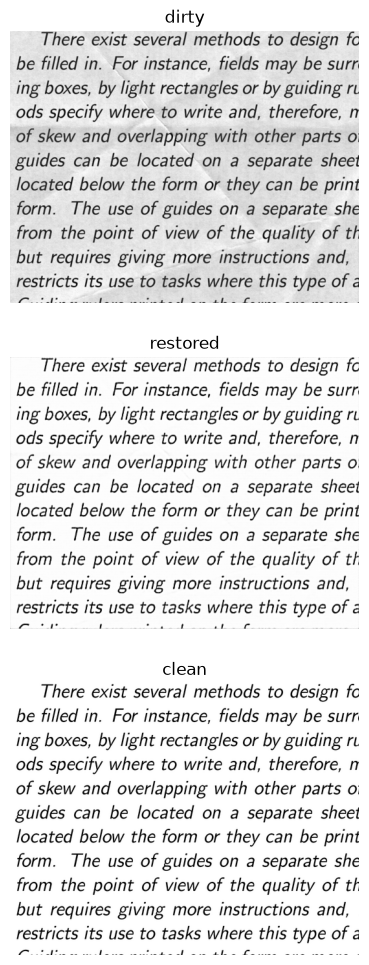

In [ ]:

# 훈련 이미지 하나를 통째로 복원 평가
# 첫 번째 파일 이름으로 손상 이미지와 정답 이미지를 열어서 흑백("L")으로 변환하고 0~1 텐서로 만듭 / 이때 shape은 (1, H, W)
name = train_dataset.files[0]

dirty_full = TF.to_tensor(Image.open(f'data/denoising-dirty-doc/train/{name}').convert('L'))
clean_full = TF.to_tensor(Image.open(f'data/denoising-dirty-doc/train_cleaned/{name}').convert('L'))
restored_full = denoise_full_image(model, dirty_full) #결과 shape은 dirty_full과 같은 (1, H, W)

#픽셀별 오차 ** 2 -> 제곱 -> .mean() 전체 픽셀 평균 (= MSE) ->  torch.sqrt: 제곱근 (= RMSE)
rmse = torch.sqrt(((restored_full - clean_full) ** 2).mean())  
# print(f"RMSE: {rmse:.4f}")
#비교 기준(baseline)을 함께 출력
rmse_base = torch.sqrt(((dirty_full - clean_full) ** 2).mean())
print(f"Baseline dirty RMSE: {rmse_base:.4f} -> restored RMSE: {rmse:.4f}")

#plt.subplots(3, 1): 세로로 3칸짜리 그림판을 만듭니다
fig, axes = plt.subplots(3, 1, figsize=(10, 12)) 
                      #zip(...): 칸, 이미지, 제목을 하나씩 짝지어 반복
for ax, img, title in zip(axes, [dirty_full, restored_full, clean_full], ["dirty", "restored", "clean"]):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1) 
            #img.squeeze(): (1, H, W)에서 채널 차원을 제거해 (H, W)로 만듭니다.
            #imshow는 2차원 흑백 이미지를 받습니다.
            #cmap="gray": 회색조로 표시
            #vmin=0, vmax=1 밝기 범위 고정
    ax.set_title(title)
    ax.axis("off") #axis("off"): 축 눈금을 숨깁니다.
plt.show()


dirty RMSE: 0.1470 -> restored RMSE: 0.0792


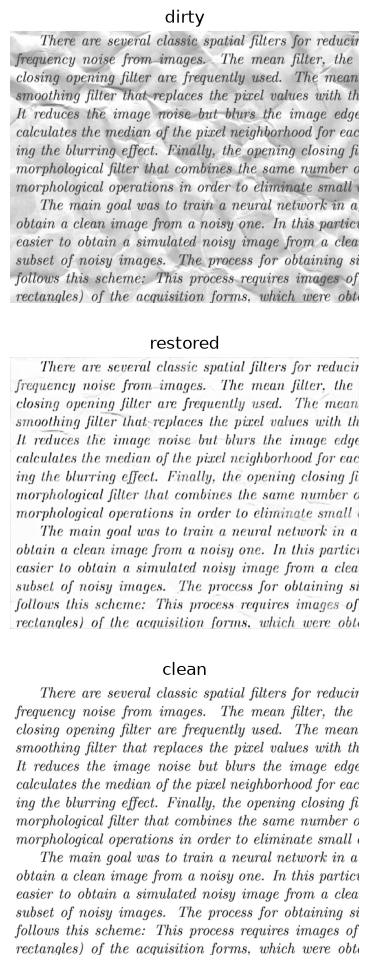

In [44]:

# val_dataset 이미지 하나를 통째로 복원 평가
# val_dataset 첫 번째 파일 이름으로 손상 이미지와 정답 이미지를 열어서 흑백("L")으로 변환하고 0~1 텐서로 만듭 / 이때 shape은 (1, H, W)
name = val_dataset.files[0]

dirty_full = TF.to_tensor(Image.open(f'data/denoising-dirty-doc/train/{name}').convert('L'))
clean_full = TF.to_tensor(Image.open(f'data/denoising-dirty-doc/train_cleaned/{name}').convert('L'))
restored_full = denoise_full_image(model, dirty_full) #결과 shape은 dirty_full과 같은 (1, H, W)

#픽셀별 오차 ** 2 -> 제곱 -> .mean() 전체 픽셀 평균 (= MSE) ->  torch.sqrt: 제곱근 (= RMSE)
rmse = torch.sqrt(((restored_full - clean_full) **2).mean())  
rmse_base = torch.sqrt(((dirty_full - clean_full) ** 2).mean())
print(f"dirty RMSE: {rmse_base:.4f} -> restored RMSE: {rmse:.4f}")

#plt.subplots(3, 1): 세로로 3칸짜리 그림판을 만듭니다
fig, axes = plt.subplots(3, 1, figsize=(10, 12)) 
                      #zip(...): 칸, 이미지, 제목을 하나씩 짝지어 반복
for ax, img, title in zip(axes, [dirty_full, restored_full, clean_full], ["dirty", "restored", "clean"]):
    ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1) 
            #img.squeeze(): (1, H, W)에서 채널 차원을 제거해 (H, W)로 만듭니다.
            #imshow는 2차원 흑백 이미지를 받습니다.
            #cmap="gray": 회색조로 표시
            #vmin=0, vmax=1 밝기 범위 고정
    ax.set_title(title)
    ax.axis("off") #axis("off"): 축 눈금을 숨깁니다.
plt.show()


## 1-5. 품질 높이기 작업
Baseline은 얕은 오토인코더라 흐릿한 얼룩 정도만 지웁니다. 아래 방향들을 실험하며 복원 품질을 높여 보세요.
- 인코더/디코더를 더 깊게 쌓거나 채널 수를 늘려 보기 (BatchNorm 추가 포함)
- 인코더의 중간 출력을 디코더에 이어 주는 스킵 커넥션 추가해 보기
- 좌우 반전, 밝기 조절 같은 데이터 증강 적용해 보기
- 검증 세트를 나눠 과적합 여부를 확인하고, test 이미지 복원 결과 비교하기
- 평가 지표에 PSNR을 추가하고, 복원이 잘 안 되는 손상 유형 분석하기

## 1-5.0. 기본 import 및 상수 설정

In [1]:
## 0 코드 재구성을 다시하기 위해 앞전 코드와 무관한게 import 재설정 
import os
import math
import random
 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
 
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader

## 이미 파일 경로 설정
DATA_DIR = "data/denoising-dirty-doc"
DIRTY_DIR = f"{DATA_DIR}/train"           # 손상 이미지 (144장)
CLEAN_DIR = f"{DATA_DIR}/train_cleaned"   # 정답 이미지 (144장)
TEST_DIR = f"{DATA_DIR}/test"             # 정답 없는 test 이미지 (72장)

# ---- 하이퍼파라미터 ----
SEED = 42
CROP = 128          # 학습용 패치 크기 (8의 배수여야 함: U-Net이 2배씩 3번 줄임)
BATCH_SIZE = 16     # 16개 이미지를 처리하는 배치 사이즈 지정
REPEAT = 4          # 이미지 한 장에서 에포크당 이미지 1장에서 뽑는 랜덤 패치 수 
N_VAL = 24          # 검증용으로 떼어 둘 이미지 수 (144장 중)
EPOCHS = 40         # 전체 이미지 학습 횟수
LR = 1e-3           # 학습율
BASE_CH = 32        # U-Net 첫 층 채널 수. 32 -> 32/64/128/256
TRAIN_SHALLOW = True   # 기존 얕은 오토인코더도 같은 조건으로 학습해 비교할지 여부
 
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
print("device:", DEVICE)


device: cpu


In [12]:
import os
for f in ["best_shallow.pth", "best_unet.pth"]:
    if os.path.exists(f):
        os.remove(f)

## 1-5.1.데이터: 이미지 캐시 + 증강이 들어간 패치 데이터셋 정의

In [2]:
# 1. 데이터: 이미지 캐시 + 증강이 들어간 패치 데이터셋

#이미지 파일이름 리스트로 읽어오는 함수
def list_pngs(folder):
    return sorted(f for f in os.listdir(folder) if f.lower().endswith(".png"))

#시작할 때 한 번만 디스크에서 읽어 uint8 텐서로 메모리에 담기
class PairCache:
    """
    (dirty, clean) 이미지를 한 번만 읽어 uint8 텐서로 메모리에 보관합니다.
    144장 * 2 약 65MB, 매 에포크 디스크를 다시 읽지 않도록
    """

    def __init__(self, dirty_dir, clean_dir, files):
        self.items = {}
        for f in files:
            d = TF.pil_to_tensor(Image.open(os.path.join(dirty_dir, f)).convert('L')) #흑백 # uint8, 0~255 그대로
            c = TF.pil_to_tensor(Image.open(os.path.join(clean_dir, f)).convert('L')) #흑백 # uint8, 0~255 그대로
            self.items[f] = (d, c)  #uint8 , shape(1, H, W), 0~255 그대로

    def get(self, name):
        """전체 이미지를 0 ~1 float 텐서로 반환"""
        d, c = self.items[name]
        return d.float() / 255.0, c.float() / 255.0  
        #이미지 픽셀은 8비트로 저장되어 0(검정)~255(흰색) 정수값을 가집니다. 
        # 이를 255.0으로 나누면 0~1 범위의 실수로 정규화됩니다.

class PatchDataset(Dataset):
    """ 학습용: 이미지에서 랜덤 위치의 CROP * CROP 패치를 뽑고 증강을 적용
        repeat =4 이면 한 에포크에 이미지 1장당 서로 다른 패치를 4개 봅니다.
        augment=True 이면 데이터 증강 - 좌우, 상하 반전 시킴
    """

    def __init__(self, cache, files, crop=128, repeat=4, augment=True, brightness=(0.85,1.15)):
        self.cache, self.files = cache, list(files)
        self.crop, self.repeat = crop, repeat
        self.augment = augment # augment: 증강 여부를 저장하는 변수
        self.brightness = brightness 

    def __len__(self):
        return len(self.files) * self.repeat #

    def __getitem__(self, idx):
        name = self.files[idx % len(self.files)] #나머지 연산으로 에러없이 갖고 있는 파일 내에서 인덱스제공
        dirty, clean = self.cache.items[name] # uint8 (1, H, W)
        _, H, W = dirty.shape 
        cs = self.crop 
        top = random.randint(0, H - cs)
        left= random.randint(0, W - cs)
        #같은 위치를 똑같이 자르고 형변환 (1, H, W)
        dirty = dirty[:, top:top + cs, left:left + cs].float() / 255.0
        clean = clean[:, top:top + cs, left:left + cs].float() / 255.0

        if self.augment: #증강 =True 일때 실행
            #(1) 좌우/상하 반전: 쌍에 똑같이 적용
            if random.random() < 0.5: # 50%(0.5)의 확률로 실행
                dirty, clean = dirty.flip(-1), clean.flip(-1) 
                #맨 마지막 차원(-1)인 가로(W) 축을 기준으로 뒤집기(좌우반전)
            if random.random() < 0.5: # 50%(0.5)의 확률로 실행
                dirty, clean = dirty.flip(-2), clean.flip(-2) 
                #뒤에서 두 번째 차원(-2)인 세로(H) 축을 기준으로 뒤집기(상하반전)

            #(2)밝기 조절: dirty에만 적용합니다.
            #   스캔 노출이 달라도 정답(clean)은 항상 "힌 배경"이 되도록 학습
            #   clean까지 어둡게 만들면 회색 종이를 출력하도록 학습
            # * 기호는 파이썬의 언패킹(Unpacking, 풀기) 연산자
            gain = random.uniform(*self.brightness) ## 예: 0.5 ~ 1.0 사이의 무작위 값 추출
            dirty = (dirty * gain).clamp(0.0, 1.0)  ## dirty에만 gain을 곱해 어둡게 만듦

        return dirty, clean         


## 1-5.2. 모델 정의: 기존 얕은 오토인코더(비교용)와 신규 U-Net 정의

In [3]:
# 2. 모델: 기존 얕은 오토인코더(비교용)와 신규 U-Net
# --- 기존 baseline 모델 시작
class ShallowAE(nn.Module):
    """기존에 쓰던 얕은 오토인코더 (비교 기준선)"""

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1), nn.Sigmoid(),
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))
# --- 기존 baseline 모델 종료

#-- U-Net 모델 시작
def conv_block(in_c, out_c): #U-Net의 기본 단위
    """Conv-BN-ReLU를 두 번 반복. BatchNorm 앞의 Conv는 bias가 필요 없음"""
    return nn.Sequential(
        nn.Conv2d(in_c, out_c, 3, padding=1, bias=False), #bias=False 파라미터만 아끼는 관행적 처리, BatchNorm이 자체적으로 평균을 빼고 다시 이동
        nn.BatchNorm2d(out_c), #데이터의 평균과 분산을 이용해 출력값의 분포를 평균 0, 분산 1로 표준화
        nn.ReLU(inplace=True),
        nn.Conv2d(out_c, out_c, 3, padding=1, bias=False),
        nn.BatchNorm2d(out_c), #데이터의 평균과 분산을 이용해 출력값의 분포를 평균 0, 분산 1로 표준화
        nn.ReLU(inplace=True),        
    )
#오토인코더의 '흐릿해지는 문제'를 해결하기 위해 스킵 커넥션(Skip Connection) 추가한 모델
class UNetDenoiser(nn.Module):
    """ 
    입력 (B,1,H,W) --> 출력 (B,1,H,W), H/W는 8의 배수
        enc1 (base)  H
        enc2 (2base) H/2
        enc3 (4base) H/4
        bottleneck (8base) H/8
        dec3 (4base) H/4 <- up + concat <- enc3 스킵: 압축되기 전의 정보(위치, 형태 등)를 디코더에게 그대로 복사해서 넘김
        dec2 (2base) H/2 <- up + concat <- enc2 스킵: 압축되기 전의 정보(위치, 형태 등)를 디코더에게 그대로 복사해서 넘김
        dec1 (1base) H   <- up + concat <- enc1 스킵: 압축되기 전의 정보(위치, 형태 등)를 디코더에게 그대로 복사해서 넘김
    """

    def __init__(self, base=32):
        super().__init__()
        c1, c2, c3, c4 = base, base*2, base*4, base*8 #인코더 4단계
        self.enc1 = conv_block(1, c1)   #(B, c1, H, W)
        self.enc2 = conv_block(c1, c2)  #(B, c2, H/2, W/2) 크기줄이기
        self.enc3 = conv_block(c2, c3)  #(B, c3, H/4, W/4) 크기줄이기
        self.enc4 = conv_block(c3, c4)  #(B, c4, H/8, W/8) 크기줄이기
        self.pool = nn.MaxPool2d(2) #특징 맵(Feature Map)의 가로·세로 크기를 1/2로 줄이기
        #stride=2 Conv 대신 pooling을 쓴 이유는,
        #- 다운샘플링(pooling)과 특징 추출(conv_block)의 역할을 분리하면 구조가 더 명확하고 U-Net의 표준 방식

        #특징 맵의 가로·세로 크기를 확장 *8 -> *4 두배로 늘림
        self.up3 = nn.ConvTranspose2d(c4, c3, kernel_size=2, stride=2) 
        #다시 원래 크기로 압축(연산)하면서, 두 정보(업샘플링된 정보 + 스킵 커넥션 정보)를 융합용
        self.dec3 = conv_block(c3*2, c3) #concat 후 *2 늘어난 채널을 압축 처리
        #특징 맵의 가로·세로 크기를 확장
        self.up2 = nn.ConvTranspose2d(c3, c2, kernel_size=2, stride=2)
        #다시 원래 크기로 압축(연산)하면서, 두 정보(업샘플링된 정보 + 스킵 커넥션 정보)를 융합용
        self.dec2 = conv_block(c2*2, c2) #concat 후 *2 늘어난 채널을 압축 처리
        #특징 맵의 가로·세로 크기를 확장
        self.up1 = nn.ConvTranspose2d(c2, c1, kernel_size=2, stride=2)
        #다시 원래 크기로 압축(연산)하면서, 두 정보(업샘플링된 정보 + 스킵 커넥션 정보)를 융합용
        self.dec1 = conv_block(c1*2, c1) #concat 후 *2 늘어난 채널을 압축 처리
        #원래 크기로 출력
        self.head = nn.Conv2d(c1, 1, kernel_size=1) # 1*1 conv: 채널-> 1장

    def forward(self, x):
        ec1 = self.enc1(x)              #(B, c1, H, W)
        ec2 = self.enc2(self.pool(ec1)) #(B, c2, H/2, W/2)
        ec3 = self.enc3(self.pool(ec2)) #(B, c3, H/4, W/4)
        ec4 = self.enc4(self.pool(ec3)) #(B, c4, H/8, W/8)

        dc3 = self.dec3(torch.cat([self.up3(ec4), ec3], dim=1)) #dim=1채널 기준으로 합치기
        dc2 = self.dec2(torch.cat([self.up2(dc3), ec2], dim=1)) #dim=1채널 기준으로 합치기
        dc1 = self.dec1(torch.cat([self.up1(dc2), ec1], dim=1)) #dim=1채널 기준으로 합치기

        return torch.sigmoid(self.head(dc1)) #출력 0~1 (clean 픽셀 범위와 동일)
#-- U-Net 모델 종료

def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)



## 1-5.3. 전체 이미지 복원 + 지표 (RMSE, PSNR) 확인 함수 정의
- RMSE(Root Mean Squared Error): 평균 제곱근 오차 - 두 이미지의 같은 위치에 있는 픽셀끼리 빼서 오차를 구한 뒤, 이를 제곱하여 평균을 내고(MSE), 마지막에 루트(Root)를 씌운 값입니다.
- PSNR(Peak Signal-to-noise Ratio): 이미지의 최대 신호 전력(정상적인 정보) 대비 잡음(오차/노이즈)의 비율을 나타내는 지표, 화질 손실이 얼마나 일어났는지 평가하기 위해 사용하며, 단위는 dB(데시벨)을 사용합니다. 수식적으로는 방금 설명해 드린 MSE(오차의 제곱 평균)를 분모에 두고 계산합니다.

In [ ]:
# 3. 전체 이미지 복원 + 지표 (RMSE, PSNR)
@torch.no_grad() #함수 전체에 Gradient 계산 중지 처리
def denoise_full_image(model, img, multiple=8): #U-Net은 pooling을 3번 하므로 높이·너비가 8의 배수여야 합니다.
    """
    (1,H,W) 이미지를 통째로 복원, U-Net은 8의 배수 크기가 필요
    - U-Net은 pooling을 3번 하므로 입력 크기가 8의 배수여야 정확히 복원됩니다
    오르쪽/아래를 reflect 패딩한 뒤 복원하고, 원래 크기로 잘라 돌려줍니다.
    258 * 540 , 420 * 540 2가지 이미지 패딩처리
    print((-258) % 8, (-420) % 8, (-540) % 8)   # 6, 4, 4
    """
    model.eval()
    _, h, w = img.shape
    pad_h = (-h) % multiple #이미 배수면 0 - (multiple - h%multiple) % multiple과 결과는 같고 더 짧게 쓴 것
    pad_w = (-w) % multiple #이미 배수면 0 - 높이/너비가 얼마든 상관없이 그 값에 맞춰 패딩을 자동 계산
    x = F.pad(img.unsqueeze(0), (0, pad_w, 0, pad_h), mode='reflect') #패딩을 자동 계산
    out = model(x.to(DEVICE)).cpu()
    return out[0, :, :h, :w]

def psnr_from_mse(mse, eps=1e-10):
    """
    PSNR(Peak Signal-to-Noise Ratio, 최대 신호 대 잡음비)은 이미지 복원 품질의 표준 지표입니다.
    PSNR(db) = 10 * log10(MAX^2 / MSE), 픽셀 범위가 0~1 이므로 MAX=1 
    MSE가 작을수록(복원이 잘될수록) PSNR은 커집니다
    """
    return 10.0 * math.log10(1.0 / max(mse, eps))

def evaluate_full(model, cache, files):
    """전체 이미지 기준(RMSE, PSNR)
    RMSE: 모든 이미지의 모든 픽셀을 합친 값
    PSNR: 이미지별 PSNR의 평균
    """
    sq_sum, n_pix, psnrs = 0.0, 0, [] #초기화
    for f in files:
        dirty, clean = cache.get(f) #cache에서 파일 가져오기
        restored = denoise_full_image(model, dirty) # 이미지 처리시 multiple=8 기본값으로 패딩처리 후 복원 모델 실행
        se = (restored - clean) **2 #복원과 결과의 차이 = 오차 점수
        sq_sum += se.sum().item()   #모든 se(오차) 원소를 더한 뒤, 그 텐서의 순수한 숫자(Scalar) 타입으로 변환 후 더하기 연산   
        n_pix += se.numel()         #"Number of Elements"의 줄임말,텐서(Tensor) 안에 들어있는 전체 원소(데이터)의 개수를 반환하는 함수
        psnrs.append(psnr_from_mse(se.mean().item())) # 모니터 평가 및 그래프용 정보 저장
    return math.sqrt(sq_sum/n_pix), float(np.mean(psnrs))
        #math.sqrt(sq_sum/n_pix): math.sqrt() ->제곱근 함수, sq_sum/n_pix->모든 픽셀 오차를 하나의 커다란 데이터셋으로 보고 RMSE계산
        #float(np.mean(psnrs)) : 이미지별 화질 점수의 평균 PSNR

## 1-5.4. 학습 함수 정의 (검증 곡선 기록 + 최적 가중치 저장)

In [ ]:
# 4. 학습 함수 (검증 곡선 기록 + 최적 가중치 저장)
def train_model(model, name, train_loader, cache, val_files, probe_files, 
                epochs=EPOCHS, lr=LR):
    """ 
    매 에포크마다 기록하는 값
    - train_patch_rmse: 학습 패치(증강 적용)에서는 RMSE (학습 중 값, BN 학습 모드)
    - probe_rmse    : 학습 이미지 일부(probe)를 '전체 이미지+평가 모드'로 잰 RMSE
    - val_rmse      : 한 번도 학습에 쓰지 않은 검증 이미지의 RMSE
    - probe 와 val 을 같은 방식으로 재므로 둘의 차이가 곧 일반화 격차
    """
    model.to(DEVICE) #모델을 DEVICE로 이동 
    #손실오차 계산용 객체생성
    criterion = nn.MSELoss() #평균제곱오차(Mean Squared Error, MSE) 손실 함수
    #.AdamW: Adam에 weight decay(가중치가 너무 커지지 않도록 누르는 정규화)가 더 정확하게 적용된 버전
    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    #.CosineAnnealingLR 학습률을 코사인 스케줄링 방식으로 변경하겠다고 선언하는 클래스입니다
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs) 
                #T_max=epochs: 학습률이 최댓값에서 최솟값까지 떨어지는 데 걸리는 총 주기(Step 수)를 설정
    best_val, best_path, rows = float("inf"), f"best_{name}.pth", []

    for epoch in range(1, epochs + 1):
        model.train() # evaluate가 eval로 바꿔 두므로 시작 시 매번 train으로 선언
        running = 0.0

        for dirty, clean in train_loader:
            dirty, clean = dirty.to(DEVICE), clean.to(DEVICE) # 데이터를 모두 똑같은 DEVICE로 이동
            optimizer.zero_grad() #가중치 저장소 초기화
            loss = criterion(model(dirty), clean) #순전파 후 pred - clean과 오차값 계산 
            loss.backward()     # 역전파로 기울기 계산
            optimizer.step()    # 기울기를 이용해 가중치(w)를 업데이트
            running += loss.item() * len(dirty) #[평균 손실] * [데이터 개수] = 손실총합

        scheduler.step() #스케줄러가 현재 시점에 맞춰 옵티마이저의 학습률을 다음 단계의 값으로 업데이트
        #초기 학습률이 0.001이고 T_max(epochs)=100이라고 가정하면, 학습률은 직선으로 떨어지지 않고 다음과 같은 곡선을 그리며 변함
        #코사인 스케줄러는 최적의 화질 스코어를 쥐어짜 내기 위해 거의 필수

        train_rmse = math.sqrt(running / len(train_loader.dataset))
        probe_rmse, probe_psnr = evaluate_full(model, cache, probe_files) #평가함수를 통해 RMSE와 PSNR 값 받아오기
        val_rmse, val_psnr = evaluate_full(model, cache, val_files)  #평가함수를 통해 RMSE와 PSNR 값 받아오기

        #평가 RMSE 정보 저장
        rows.append(dict(epoch=epoch, train_patch_rmse=train_rmse, 
                        probe_rmse=probe_rmse, val_rmse=val_rmse,
                        probe_psnr=probe_psnr, val_psnr=val_psnr
        ))
        #검증 성능이 가장 좋은 시점을 저장
        if val_rmse < best_val: 
            best_val = val_rmse
            torch.save(model.state_dict(), best_path) #best_path 변수에 저장

        #epoch 1 부터 5회 마다 train & probe - RMSE, validation - RMSE 값을 출력
        if epoch ==1 or epoch % 5 ==0:
            # print(type(val_rmse), val_rmse, "|", type(val_psnr), val_psnr)
            # print(type(probe_rmse), probe_rmse, "|", type(probe_psnr), probe_psnr)
            print(f"[{name}] epoch {epoch:3d} | train {train_rmse:.4f} | "
                  f"probe {probe_rmse:.4f} | val {val_rmse:.4f} | "
                  f"val PSNR {val_psnr:5.2f} dB")          
            
    model.load_state_dict(torch.load(best_path, map_location=DEVICE)) ##best_path 변수에서 가져오기
    print(f"[{name}] 최적 val RMSE {best_val:.4f} (가중치 {best_path})") #학습완료 후 메시지
    return pd.DataFrame(rows) #epoch마다 기록한 RMSE, PSNR 값 dictionary 반환



## 1-5.5. 데이터 분리 + 증강된 파일 확인 

전체 학습 이미지 수: 144
train 120장 / val 24장
에포크당 패치 수: 480 | 배치 수: 30


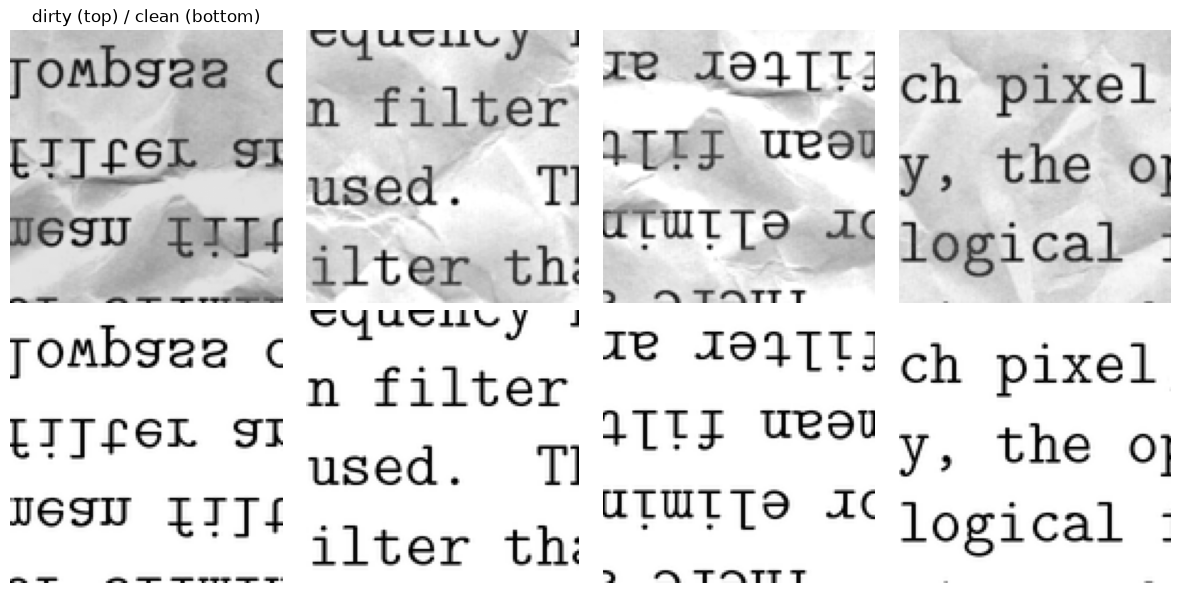

In [6]:
# 5. 데이터 분리 + 증강 확인
all_files = list_pngs(DIRTY_DIR)
print("전체 학습 이미지 수:", len(all_files))

shuffled = all_files[:]

random.Random(SEED).shuffle(shuffled)               # 재현 가능한 분할
val_files, train_files = shuffled[:N_VAL], shuffled[N_VAL:]

probe_files = train_files[:N_VAL]                   # 과적합 비교용: 학습 이미지 중 일부
print(f"train {len(train_files)}장 / val {len(val_files)}장")

cache = PairCache(DIRTY_DIR, CLEAN_DIR, all_files)
train_ds = PatchDataset(cache, train_files, crop=CROP, repeat=REPEAT, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
print("에포크당 패치 수:", len(train_ds), "| 배치 수:", len(train_loader))

# ## 학습 이미지 수량 검토
# n_orig = len(train_files)
# n_per_epoch = len(train_ds)              # = n_orig * REPEAT
# n_total = n_per_epoch * EPOCHS           # 전체 학습 동안 누적으로 보는 패치 수

# print(f"원본 학습 이미지 수:          {n_orig}장")
# print(f"이미지당 반복 추출(REPEAT):   {REPEAT}개 패치")
# print(f"에포크당 학습 패치 수:        {n_per_epoch}개  (= {n_orig} x {REPEAT})")
# print(f"배치 크기 / 배치 수:         {BATCH_SIZE} / {len(train_loader)}")
# print(f"총 EPOCHS:                 {EPOCHS}")
# print(f"전체 학습 동안 누적 패치 수:  {n_total}개  (= {n_per_epoch} x {EPOCHS})")

def preview_augmentation(ds, n=4):
    """같은 이미지에서 증강된 패치 여러 개를 뽑아 dirty/clean 쌍이 잘 맞는지 확인"""
    fig, axes = plt.subplots(2, n, figsize=(3 * n, 6))
    for i in range(n):
        d, c = ds[0]
        axes[0, i].imshow(d.squeeze(), cmap="gray", vmin=0, vmax=1); axes[0, i].axis("off")
        axes[1, i].imshow(c.squeeze(), cmap="gray", vmin=0, vmax=1); axes[1, i].axis("off")
    axes[0, 0].set_title("dirty (top) / clean (bottom)")
    plt.tight_layout(); plt.show()


preview_augmentation(train_ds)

In [7]:
## 학습 이미지 수량
n_orig = len(train_files)
n_per_epoch = len(train_ds)              # = n_orig * REPEAT
n_total = n_per_epoch * EPOCHS           # 전체 학습 동안 누적으로 보는 패치 수

print(f"원본 학습 이미지 수:          {n_orig}장")
print(f"이미지당 반복 추출(REPEAT):   {REPEAT}개 패치")
print(f"에포크당 학습 패치 수:        {n_per_epoch}개  (= {n_orig} x {REPEAT})")
print(f"배치 크기 / 배치 수:         {BATCH_SIZE} / {len(train_loader)}")
print(f"총 EPOCHS:                 {EPOCHS}")
print(f"전체 학습 동안 누적 패치 수:  {n_total}개  (= {n_per_epoch} x {EPOCHS})")

원본 학습 이미지 수:          120장
이미지당 반복 추출(REPEAT):   4개 패치
에포크당 학습 패치 수:        480개  (= 120 x 4)
배치 크기 / 배치 수:         16 / 30
총 EPOCHS:                 40
전체 학습 동안 누적 패치 수:  19200개  (= 480 x 40)


In [11]:
models.items()

dict_items([])

## 1-5.6. 학습 실행

In [ ]:
# 6. 학습 실행
models, histories = {}, {}

if TRAIN_SHALLOW:
    torch.manual_seed(SEED)
    shallow = ShallowAE() #모델 객체 변수 생성
    print("ShallowAE 파라미터 수:", f"{count_params(shallow):,}")
    #Shallow모델 학습실행 및 결과 저장
    histories["shallow"] = train_model(shallow, "shallow", train_loader, cache, val_files, probe_files) 
    models["shallow"] = shallow #추후 모델 비교를 위해 모델 정보 저장

torch.manual_seed(SEED)
unet = UNetDenoiser(base=BASE_CH) #모델 객체 변수 생성
print()
print("UNet 파라미터 수:", f"{count_params(unet):,}")
#U-Net모델 학습실행 및 결과 저장
histories["unet"] = train_model(unet, "unet", train_loader, cache, val_files, probe_files) 
models["unet"] = unet #추후 모델 비교를 위해 모델 정보 저장

ShallowAE 파라미터 수: 52,129
[shallow] epoch   1 | train 0.3200 | probe 0.2802 | val 0.2790 | val PSNR 11.22 dB
[shallow] epoch   5 | train 0.1430 | probe 0.1214 | val 0.1226 | val PSNR 18.23 dB
[shallow] epoch  10 | train 0.0812 | probe 0.0698 | val 0.0739 | val PSNR 22.65 dB
[shallow] epoch  15 | train 0.0673 | probe 0.0576 | val 0.0622 | val PSNR 24.18 dB
[shallow] epoch  20 | train 0.0614 | probe 0.0527 | val 0.0571 | val PSNR 24.91 dB
[shallow] epoch  25 | train 0.0578 | probe 0.0504 | val 0.0545 | val PSNR 25.30 dB
[shallow] epoch  30 | train 0.0564 | probe 0.0491 | val 0.0532 | val PSNR 25.51 dB
[shallow] epoch  35 | train 0.0560 | probe 0.0485 | val 0.0528 | val PSNR 25.59 dB
[shallow] epoch  40 | train 0.0556 | probe 0.0484 | val 0.0527 | val PSNR 25.61 dB
[shallow] 최적 val RMSE 0.0527 (가중치 best_shallow.pth)

UNet 파라미터 수: 1,926,433
[unet] epoch   1 | train 0.2712 | probe 0.2209 | val 0.2217 | val PSNR 13.08 dB
[unet] epoch   5 | train 0.0853 | probe 0.0762 | val 0.0770 | val PSNR 2

In [14]:
for name, hist in histories.items():
    used_epochs = hist["epoch"].max()
    print(f"[{name}] 실제 학습 epoch 수: {used_epochs} | 누적 패치 수: {n_per_epoch * used_epochs}")

[shallow] 실제 학습 epoch 수: 40 | 누적 패치 수: 19200
[unet] 실제 학습 epoch 수: 40 | 누적 패치 수: 19200


## 1-5.7. 과적합 확인 (학습 곡선 vs 검증 곡선)

In [15]:
def diagnose_overfit(hist, name):
    """검증 곡선을 보고 과적합 여부를 간단히 판정합니다 (기준값은 경험적인 목안치이니 상황에 맞게 조정)."""
    best_i = hist["val_rmse"].idxmin()
    best_ep = int(hist.loc[best_i, "epoch"])
    best_val = hist.loc[best_i, "val_rmse"]
    last = hist.iloc[-1]
    gap_ratio = last["val_rmse"] / last["probe_rmse"]
    worse_after_best = last["val_rmse"] / best_val

    print(f"\n[{name}] 최적 epoch={best_ep}, 마지막 epoch={int(last['epoch'])}")
    print(f"  마지막 val/probe RMSE 비율 = {gap_ratio:.2f}  (1에 가까울수록 일반화 양호)")
    print(f"  마지막 val 이 최적 val 대비 {100 * (worse_after_best - 1):.1f}% 나쁨")
    if worse_after_best > 1.05 and best_ep < last["epoch"] - 3:
        print("  -> 과적합 징후: 최적 epoch 이후 val 이 악화. best 가중치를 쓰거나 EPOCHS/모델 크기를 줄이세요.")
    elif gap_ratio > 1.3:
        print("  -> 일반화 격차 큼: 증강 강화, weight_decay 증가, 데이터 추가를 고려하세요.")
    else:
        print("  -> 뚜렷한 과적합 징후 없음.")

def plot_history(hist, name):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist["epoch"], hist["train_patch_rmse"], label="train (patch, augmented)")
    axes[0].plot(hist["epoch"], hist["probe_rmse"],       label="train probe (full image)")
    axes[0].plot(hist["epoch"], hist["val_rmse"],         label="validation (full image)")
    axes[0].set_xlabel("epoch"); axes[0].set_ylabel("RMSE"); axes[0].set_title(f"{name}: RMSE")
    axes[0].legend(); axes[0].grid(alpha=0.3)
    axes[1].plot(hist["epoch"], hist["probe_psnr"], label="train probe")
    axes[1].plot(hist["epoch"], hist["val_psnr"], label="validation")
    axes[1].set_xlabel("epoch"); axes[1].set_ylabel("PSNR (dB)"); axes[1].set_title(f"{name}: PSNR")
    axes[1].legend(); axes[1].grid(alpha=0.3)
    plt.tight_layout(); plt.show()


[shallow] 최적 epoch=38, 마지막 epoch=40
  마지막 val/probe RMSE 비율 = 1.09  (1에 가까울수록 일반화 양호)
  마지막 val 이 최적 val 대비 0.0% 나쁨
  -> 뚜렷한 과적합 징후 없음.


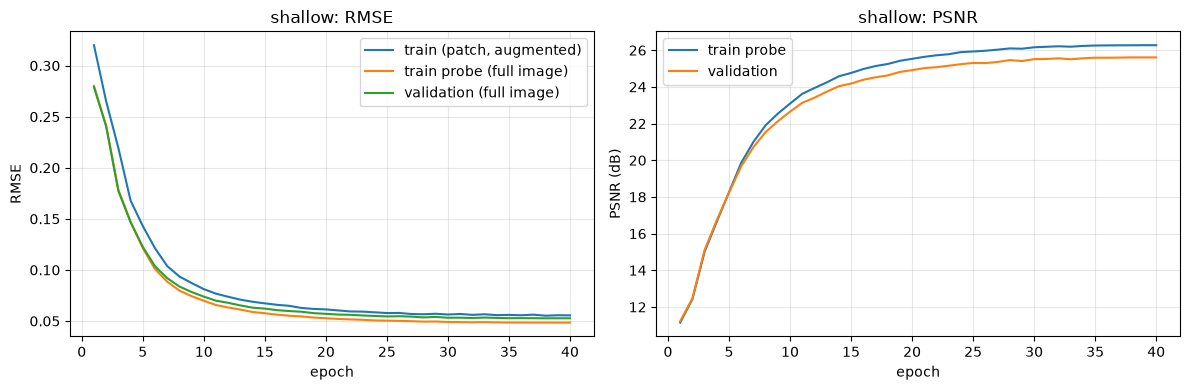


[unet] 최적 epoch=36, 마지막 epoch=40
  마지막 val/probe RMSE 비율 = 1.05  (1에 가까울수록 일반화 양호)
  마지막 val 이 최적 val 대비 0.1% 나쁨
  -> 뚜렷한 과적합 징후 없음.


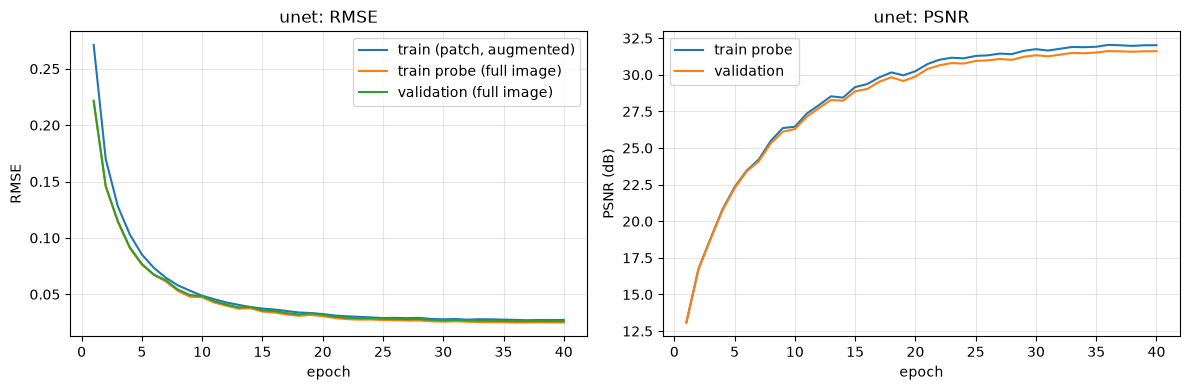

In [16]:
for name, hist in histories.items():
    diagnose_overfit(hist, name)
    plot_history(hist, name)

## 1-5.8. 검증 세트로 Baseline 모델 vs U-Net 모델 비교 
- 정답이 있으므로 수치 비교 가능

         model   RMSE  PSNR_dB
dirty (처리 안 함) 0.1616    15.94
       shallow 0.0527    25.61
          unet 0.0262    31.62


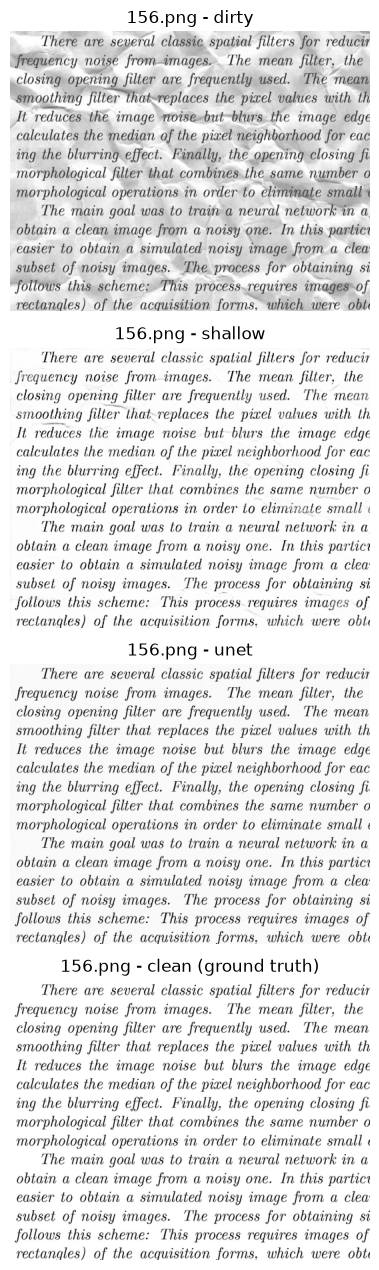

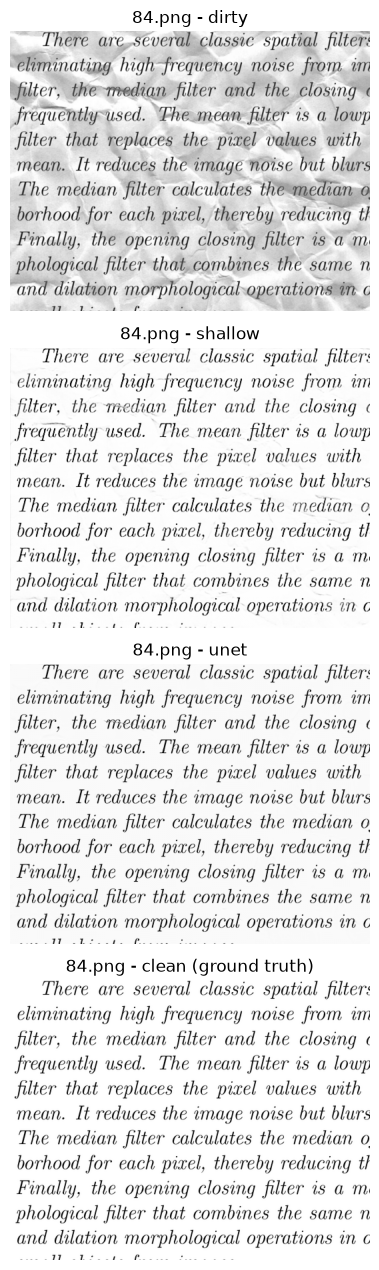

In [17]:
def compare_models(models, cache, files):
    rows = []
    baseline = nn.Identity()                 # 아무 처리도 하지 않은 손상 이미지 그대로
    for name, m in {"dirty (처리 안 함)": baseline, **models}.items():
        rmse, psnr = evaluate_full(m, cache, files)
        rows.append(dict(model=name, RMSE=round(rmse, 4), PSNR_dB=round(psnr, 2)))
    return pd.DataFrame(rows)


print(compare_models(models, cache, val_files).to_string(index=False))


def show_val_examples(models, cache, files, n=2):
    for f in files[:n]:
        dirty, clean = cache.get(f)
        panels = [("dirty", dirty)] + \
                 [(k, denoise_full_image(m, dirty)) for k, m in models.items()] + \
                 [("clean (ground truth)", clean)]
        fig, axes = plt.subplots(len(panels), 1, figsize=(9, 3.2 * len(panels)))
        for ax, (title, img) in zip(axes, panels):
            ax.imshow(img.squeeze(), cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"{f} - {title}"); ax.axis("off")
        plt.tight_layout(); plt.show()


show_val_examples(models, cache, val_files)

## 1-5.9 test 이미지 복원 (정답이 없으므로 눈으로 비교 + 파일로 저장)

72장을 'restored_test' 폴더에 저장했습니다.


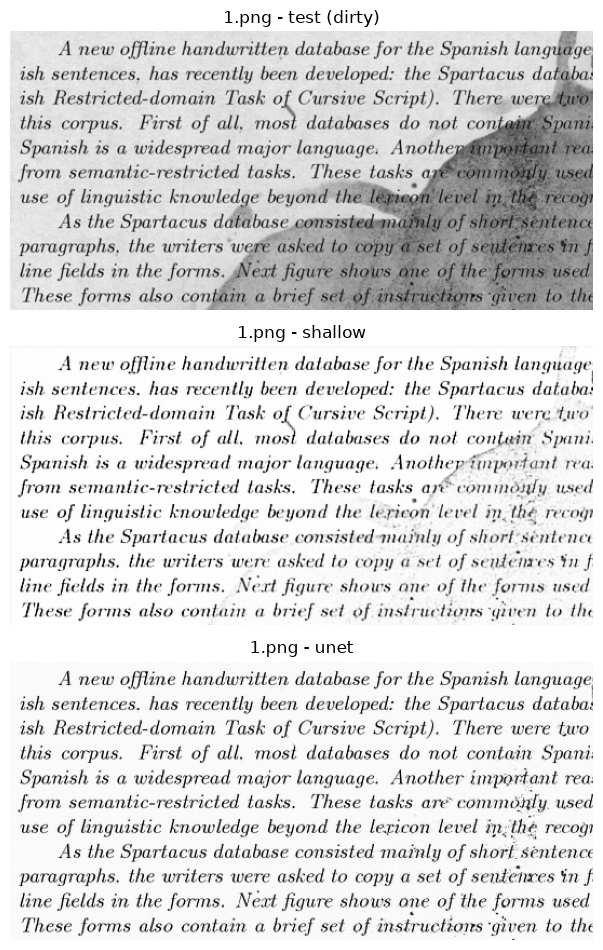

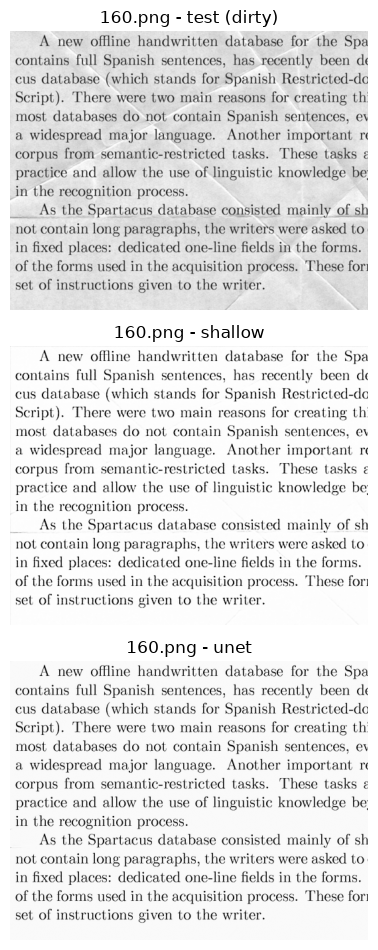

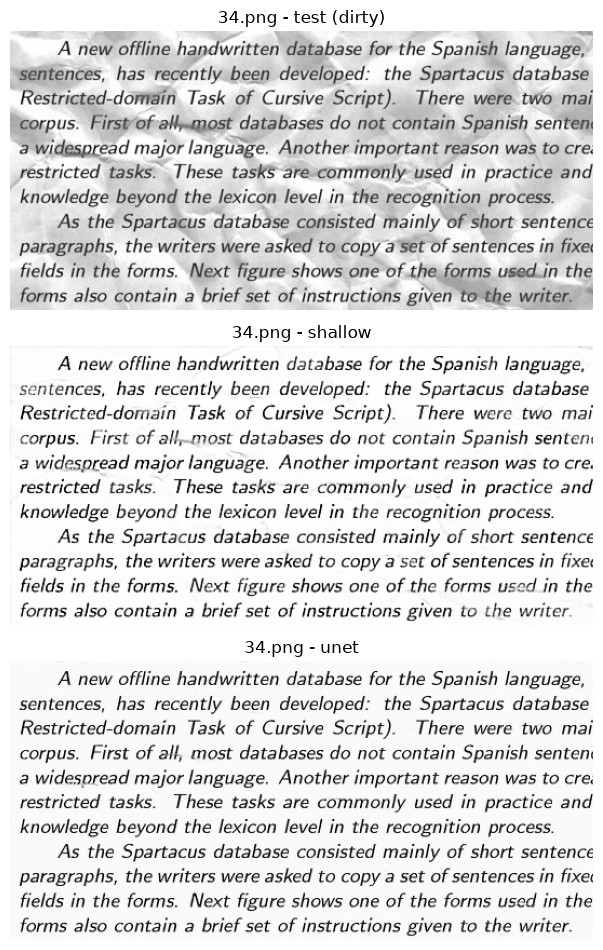

In [ ]:
# 9. test 이미지 복원 (정답이 없으므로 눈으로 비교 + 파일로 저장)

def restore_test_images(models, test_dir, save_model="unet", n_show=3, save_dir="restored_test"):
    files = list_pngs(test_dir)
    os.makedirs(save_dir, exist_ok=True)
    for f in files:                                   # 전체 test 이미지를 복원해 저장
        img = TF.to_tensor(Image.open(os.path.join(test_dir, f)).convert("L"))
        out = denoise_full_image(models[save_model], img)
        TF.to_pil_image(out).save(os.path.join(save_dir, f))
    print(f"{len(files)}장을 '{save_dir}' 폴더에 저장했습니다.")

    step = max(1, len(files) // n_show)
    for f in files[::step][:n_show]:                  # 일부를 골라 나란히 비교
        img = TF.to_tensor(Image.open(os.path.join(test_dir, f)).convert("L"))
        panels = [("test (dirty)", img)] + \
                 [(k, denoise_full_image(m, img)) for k, m in models.items()]
        fig, axes = plt.subplots(len(panels), 1, figsize=(9, 3.2 * len(panels)))
        for ax, (title, im) in zip(axes, panels):
            ax.imshow(im.squeeze(), cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"{f} - {title}"); ax.axis("off")
        plt.tight_layout(); plt.show()


def restore_test_images_single(model, test_dir, n_show=3, save_dir="restored_test_single"):
    files = list_pngs(test_dir)
    os.makedirs(save_dir, exist_ok=True)
    for f in files:
        img = TF.to_tensor(Image.open(os.path.join(test_dir, f)).convert("L"))
        out = denoise_full_image(model, img)
        TF.to_pil_image(out).save(os.path.join(save_dir, f))
    print(f"{len(files)}장을 '{save_dir}' 폴더에 저장했습니다.")

    step = max(1, len(files) // n_show)
    for f in files[::step][:n_show]:
        img = TF.to_tensor(Image.open(os.path.join(test_dir, f)).convert("L"))
        restored = denoise_full_image(model, img)
        fig, axes = plt.subplots(2, 1, figsize=(9, 6.4))
        for ax, (title, im) in zip(axes, [("test (dirty)", img), ("restored", restored)]):
            ax.imshow(im.squeeze(), cmap="gray", vmin=0, vmax=1)
            ax.set_title(f"{f} - {title}"); ax.axis("off")
        plt.tight_layout(); plt.show()
        

restore_test_images(models, TEST_DIR)

## 1-5.10. 복원이 잘 안 되는 손상 유형 분석
- 데이터셋에는 "손상 유형" 라벨이 없습니다. 그래서 (dirty - clean) 을 계산해
- 손상의 성격을 수치로 만들고, 복원 오차와 어떤 관계가 있는지 봅니다.


== 이미지별 결과 (복원 RMSE 나쁜 순) ==
   file  height  rmse_dirty  rmse_restored  psnr_restored  noise_rms  lowfreq_ratio  heavy_ratio  text_rmse  bg_rmse
  3.png     258      0.2100         0.0307        30.2695     0.2100         0.8732       0.2349     0.0474   0.0286
 35.png     258      0.1512         0.0305        30.3144     0.1512         0.7249       0.3695     0.0518   0.0262
  8.png     258      0.1940         0.0295        30.6102     0.1940         0.8893       0.7356     0.0428   0.0278
 60.png     258      0.1524         0.0292        30.6853     0.1524         0.7539       0.3767     0.0529   0.0251
  2.png     258      0.1746         0.0286        30.8765     0.1746         0.8523       0.2085     0.0395   0.0273
 95.png     420      0.1466         0.0283        30.9579     0.1466         0.7728       0.3528     0.0534   0.0248
156.png     420      0.1470         0.0279        31.0852     0.1470         0.7727       0.3512     0.0452   0.0255
152.png     420      0.1963       

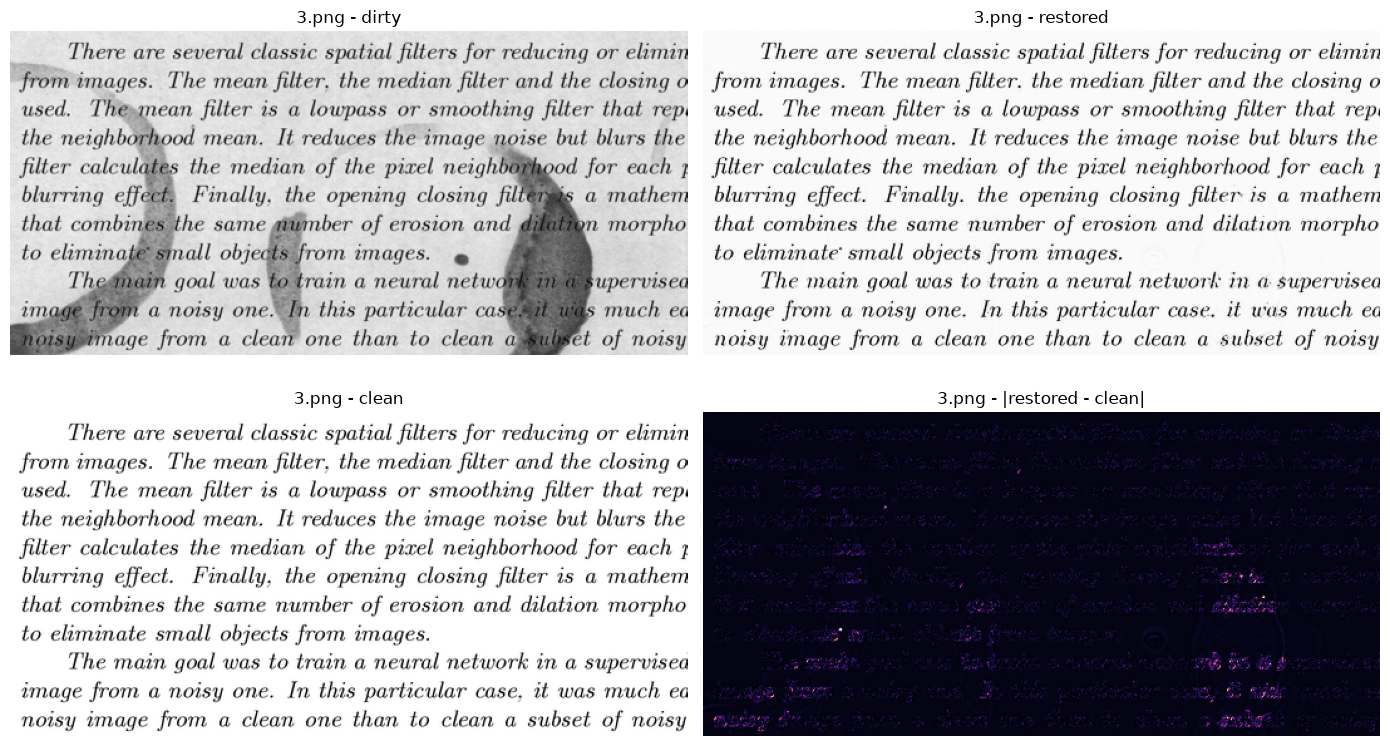

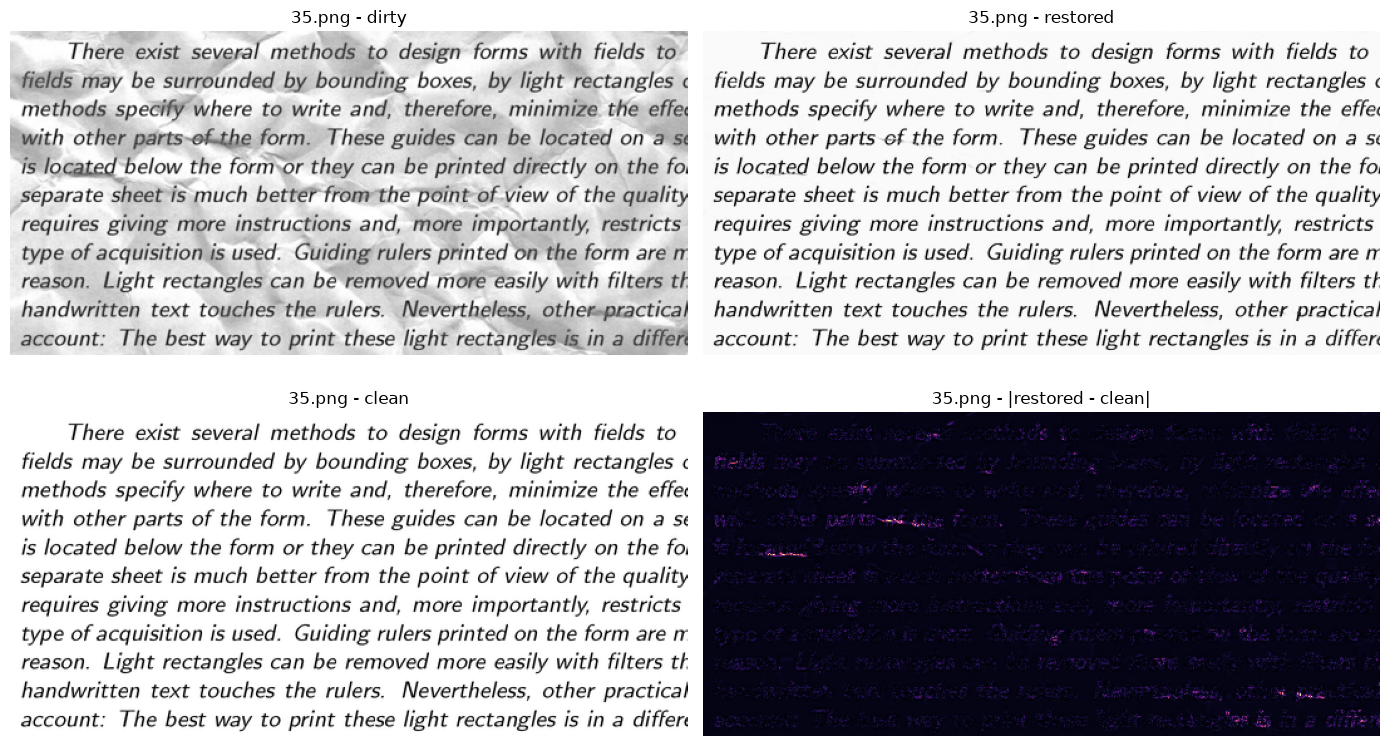

In [19]:
# 10. 복원이 잘 안 되는 손상 유형 분석
# 이 데이터셋에는 "손상 유형" 라벨이 없습니다. 그래서 (dirty - clean) 을 계산해
# 손상의 성격을 수치로 만들고, 복원 오차와 어떤 관계가 있는지 봅니다.
def analyze_errors(model, cache, files):
    rows = []
    for f in files:
        dirty, clean = cache.get(f)
        restored = denoise_full_image(model, dirty)
        se = (restored - clean) ** 2
        mse_dirty = ((dirty - clean) ** 2).mean().item()
        noise = dirty - clean                          # 손상 성분 (정답 대비 얼마나 더럽혀졌나)
        # 31x31 평균으로 흐려서 "넓은 영역에 걸친 성분(얼룩/그림자)"만 남김
        low = F.avg_pool2d(noise[None], 31, stride=1, padding=15,
                           count_include_pad=False)[0]
        noise_rms = noise.pow(2).mean().sqrt().item()
        text = clean < 0.5                             # 글자(획) 픽셀
        bg = ~text                                     # 배경 픽셀
        rows.append(dict(
            file=f,
            height=dirty.shape[1],                     # 258 / 420 : 문서 양식 종류
            rmse_dirty=math.sqrt(mse_dirty),
            rmse_restored=se.mean().sqrt().item(),
            psnr_dirty=psnr_from_mse(mse_dirty),
            psnr_restored=psnr_from_mse(se.mean().item()),
            noise_rms=noise_rms,                                       # 손상 강도
            lowfreq_ratio=low.pow(2).mean().sqrt().item() / max(noise_rms, 1e-8),  # 얼룩 성분 비율
            heavy_ratio=(noise.abs() > 0.15).float().mean().item(),    # 크게 오염된 픽셀 비율
            text_ratio=text.float().mean().item(),                     # 글자 픽셀 비율
            text_rmse=se[text].mean().sqrt().item() if text.any() else float("nan"),
            bg_rmse=se[bg].mean().sqrt().item() if bg.any() else float("nan"),
            text_err_share=(se[text].sum() / se.sum()).item() if text.any() else 0.0,
        ))
    df = pd.DataFrame(rows)
    # 손상을 "넓은 얼룩형 / 잔점형"으로 나누는 기준은 중앙값(데이터 기반)
    med = df["lowfreq_ratio"].median()
    df["type"] = np.where(df["lowfreq_ratio"] >= med, "넓은 얼룩/그림자 우세", "잔점/거친 질감 우세")
    return df


def report_errors(df):
    cols = ["file", "height", "rmse_dirty", "rmse_restored", "psnr_restored",
            "noise_rms", "lowfreq_ratio", "heavy_ratio", "text_rmse", "bg_rmse"]
    print("\n== 이미지별 결과 (복원 RMSE 나쁜 순) ==")
    print(df.sort_values("rmse_restored", ascending=False)[cols].round(4).to_string(index=False))

    agg = ["rmse_dirty", "rmse_restored", "psnr_restored", "text_rmse", "bg_rmse"]
    print("\n== 손상 성격별 평균 ==")
    print(df.groupby("type")[agg].mean().round(4).to_string())
    print("\n== 문서 크기(양식)별 평균 ==")
    print(df.groupby("height")[agg].mean().round(4).to_string())

    print("\n== 오차가 어디서 나는가 ==")
    print(f"글자 픽셀이 전체 픽셀의 {100 * df['text_ratio'].mean():.1f}% 인데, "
          f"전체 제곱오차의 {100 * df['text_err_share'].mean():.1f}% 를 차지")

    num = ["noise_rms", "lowfreq_ratio", "heavy_ratio", "text_ratio", "rmse_restored"]
    print("\n== 복원 RMSE 와 손상 특성의 상관계수 ==")
    print(df[num].corr()["rmse_restored"].drop("rmse_restored").round(3).to_string())


def show_worst(model, cache, df, k=2):
    for f in df.sort_values("rmse_restored", ascending=False)["file"].head(k):
        dirty, clean = cache.get(f)
        restored = denoise_full_image(model, dirty)
        err = (restored - clean).abs()
        fig, axes = plt.subplots(2, 2, figsize=(14, 8))
        for ax, (title, im, kw) in zip(axes.ravel(), [
                ("dirty", dirty, dict(cmap="gray", vmin=0, vmax=1)),
                ("restored", restored, dict(cmap="gray", vmin=0, vmax=1)),
                ("clean", clean, dict(cmap="gray", vmin=0, vmax=1)),
                ("|restored - clean|", err, dict(cmap="magma", vmin=0, vmax=0.5))]):
            ax.imshow(im.squeeze(), **kw); ax.set_title(f"{f} - {title}"); ax.axis("off")
        plt.tight_layout(); plt.show()


analysis = analyze_errors(models["unet"], cache, val_files)
report_errors(analysis)
show_worst(models["unet"], cache, analysis, k=2)

## U-Net 추가 개선 시도(Fine-Tune)
1. 모델 용량 키우기 - 과적합이 아니므로 채널 수를 늘려 추가 실험 가능
    - BASE_CH = 64   # 32 -> 64 (파라미터 약 190만 -> 770만)
2. 학습을 더 길게, 스케줄을 개선
    - EPOCHS = 80
    - 스케줄러를 warm restart 방식으로 바꾸면, 학습률이 주기적으로 다시 올라갔다 내려오며 지역 최적점을 벗어날 기회를 줍니다.
    scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=1)


In [20]:
## 방법 2: 간단하게 - 지금 가중치에서 이어서 추가 Epoch 학습 후 모니터
EXTRA_EPOCHS = 25
FINETUNE_LR = 3e-4     # 이어서 학습할 때는 원래 lr(1e-3)보다 낮게 시작하는 것이 안전

unet_more = UNetDenoiser(base=BASE_CH)
unet_more.load_state_dict(torch.load("best_unet.pth", map_location=DEVICE))

hist_more = train_model(
    unet_more, "unet_ft2", train_loader, cache, val_files, probe_files,
    epochs=EXTRA_EPOCHS, lr=FINETUNE_LR,
)
models["unet"] = unet_more          # 이어서 쓸 모델을 교체
histories["unet_ft"] = hist_more

[unet_ft2] epoch   1 | train 0.0284 | probe 0.0241 | val 0.0254 | val PSNR 31.88 dB
[unet_ft2] epoch   5 | train 0.0226 | probe 0.0193 | val 0.0209 | val PSNR 33.65 dB
[unet_ft2] epoch  10 | train 0.0201 | probe 0.0171 | val 0.0184 | val PSNR 34.79 dB
[unet_ft2] epoch  15 | train 0.0188 | probe 0.0165 | val 0.0178 | val PSNR 35.05 dB
[unet_ft2] epoch  20 | train 0.0183 | probe 0.0158 | val 0.0173 | val PSNR 35.34 dB
[unet_ft2] epoch  25 | train 0.0178 | probe 0.0156 | val 0.0171 | val PSNR 35.48 dB
[unet_ft2] 최적 val RMSE 0.0171 (가중치 best_unet_ft2.pth)


In [21]:
unet_more2 = UNetDenoiser(base=BASE_CH)
unet_more2.load_state_dict(torch.load("best_unet_ft2.pth", map_location=DEVICE))

hist_more2 = train_model(unet_more2, "unet_ft3", train_loader, cache, val_files, probe_files,
                         epochs=30, lr=2e-4)   # 학습률을 조금 더 낮춰서 재시작

models["unet"] = unet_more2
histories["unet_ft3"] = hist_more2

[unet_ft3] epoch   1 | train 0.0191 | probe 0.0160 | val 0.0177 | val PSNR 35.18 dB
[unet_ft3] epoch   5 | train 0.0185 | probe 0.0155 | val 0.0171 | val PSNR 35.49 dB
[unet_ft3] epoch  10 | train 0.0174 | probe 0.0150 | val 0.0163 | val PSNR 35.93 dB
[unet_ft3] epoch  15 | train 0.0170 | probe 0.0153 | val 0.0168 | val PSNR 35.69 dB
[unet_ft3] epoch  20 | train 0.0167 | probe 0.0139 | val 0.0154 | val PSNR 36.44 dB
[unet_ft3] epoch  25 | train 0.0163 | probe 0.0137 | val 0.0152 | val PSNR 36.53 dB
[unet_ft3] epoch  30 | train 0.0159 | probe 0.0137 | val 0.0151 | val PSNR 36.58 dB
[unet_ft3] 최적 val RMSE 0.0151 (가중치 best_unet_ft3.pth)


In [26]:
unet_more3 = UNetDenoiser(base=BASE_CH)
unet_more3.load_state_dict(torch.load("best_unet_ft3.pth", map_location=DEVICE))

hist_more3 = train_model(unet_more3, "unet_ft4", train_loader, cache, val_files, probe_files,
                         epochs=40, lr=1e-4)   # 학습률을 한 단계 더 낮춤
models["unet"] = unet_more3
histories["unet_ft3"] = hist_more3

[unet_ft4] epoch   1 | train 0.0170 | probe 0.0139 | val 0.0154 | val PSNR 36.46 dB
[unet_ft4] epoch   5 | train 0.0163 | probe 0.0138 | val 0.0154 | val PSNR 36.44 dB
[unet_ft4] epoch  10 | train 0.0161 | probe 0.0136 | val 0.0151 | val PSNR 36.61 dB
[unet_ft4] epoch  15 | train 0.0166 | probe 0.0135 | val 0.0149 | val PSNR 36.69 dB
[unet_ft4] epoch  20 | train 0.0156 | probe 0.0132 | val 0.0146 | val PSNR 36.91 dB
[unet_ft4] epoch  25 | train 0.0155 | probe 0.0131 | val 0.0144 | val PSNR 37.00 dB
[unet_ft4] epoch  30 | train 0.0153 | probe 0.0131 | val 0.0145 | val PSNR 36.99 dB
[unet_ft4] epoch  35 | train 0.0153 | probe 0.0130 | val 0.0144 | val PSNR 37.04 dB
[unet_ft4] epoch  40 | train 0.0151 | probe 0.0130 | val 0.0144 | val PSNR 37.02 dB
[unet_ft4] 최적 val RMSE 0.0144 (가중치 best_unet_ft4.pth)


## Fine-tune 이후 최종 모델 저장

In [27]:
FINAL_MODEL_PATH = "final_Unet_model.pth" #최종 모델이름으로 저장
torch.save(unet_more3.state_dict(), FINAL_MODEL_PATH)   # unet_more3 을 "final_Unet_model.pth"에 저장

import json

best_idx = hist_more3["val_rmse"].idxmin()               # hist_more -> hist_more3
config = {
    "model_path": FINAL_MODEL_PATH,
    "BASE_CH": BASE_CH,
    "CROP": CROP,
    "val_rmse": float(hist_more3.loc[best_idx, "val_rmse"]),
    "val_psnr": float(hist_more3.loc[best_idx, "val_psnr"]),
    "saved_at": pd.Timestamp.now().isoformat(),
}
with open("model_config.json", "w", encoding="utf-8") as f:
    json.dump(config, f, ensure_ascii=False, indent=2)

hist_more3.to_csv("unet_training_history.csv", index=False)
print(config)

{'model_path': 'final_Unet_model.pth', 'BASE_CH': 32, 'CROP': 128, 'val_rmse': 0.014386651610752163, 'val_psnr': 37.03679364702878, 'saved_at': '2026-09-23T13:03:01.398961'}


In [28]:
# 저장 직후 바로 재확인
check_model = UNetDenoiser(base=BASE_CH)
check_model.load_state_dict(torch.load(FINAL_MODEL_PATH, map_location=DEVICE))
check_model.to(DEVICE)

rmse, psnr = evaluate_full(check_model, cache, val_files)
print(f"저장된 파일 재확인: RMSE {rmse:.4f}, PSNR {psnr:.2f}dB")   # 마지막에 저장한 모델의 RMSE근처가 나와야 정상

저장된 파일 재확인: RMSE 0.0144, PSNR 37.04dB


## 저장된 모델을 로드해서 사용하기 

In [29]:
import json, torch

with open("model_config.json", encoding="utf-8") as f:
    config = json.load(f)

model = UNetDenoiser(base=config["BASE_CH"])
model.load_state_dict(torch.load(config["model_path"], map_location=DEVICE))
model.to(DEVICE).eval()

print(f"불러온 모델 (이전 기준 val RMSE {config['val_rmse']:.4f}, "
      f"PSNR {config['val_psnr']:.2f}dB)")

불러온 모델 (이전 기준 val RMSE 0.0144, PSNR 37.04dB)


In [30]:
from PIL import Image
import torchvision.transforms.functional as TF
## 로드된 모델로 이미지 복원 테스트
dirty = TF.to_tensor(Image.open("data/denoising-dirty-doc/test/1.png").convert("L"))
restored = denoise_full_image(model, dirty)

72장을 'restored_test' 폴더에 저장했습니다.


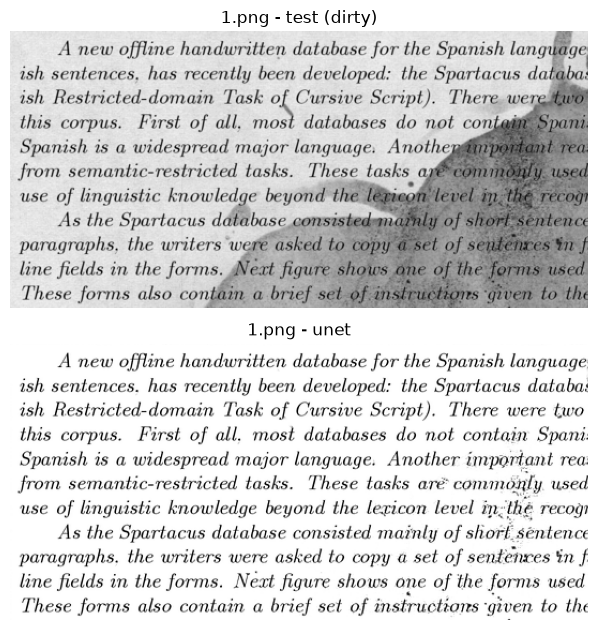

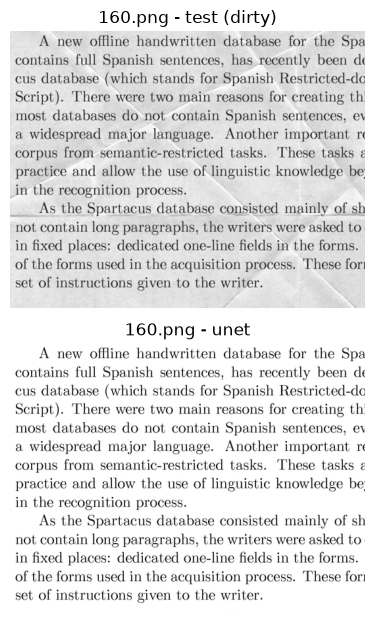

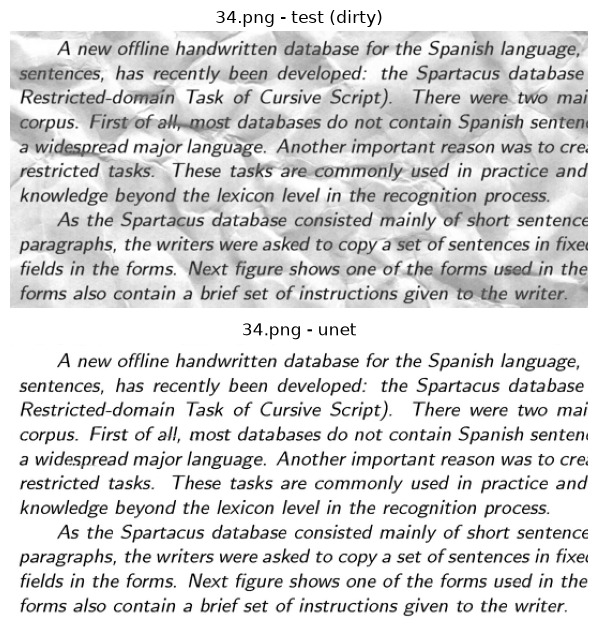

In [34]:
# final model로 이미지 복원 (정답이 없으므로 눈으로 비교 + 파일로 저장)
restore_test_images({"unet": model}, TEST_DIR)

## Kaggle 제출 파일(submission.csv) 만들기 및 제출

In [35]:
import numpy as np
import pandas as pd
from PIL import Image
import torchvision.transforms.functional as TF

#기존 샘플 읽기
sample = pd.read_csv(f"{DATA_DIR}/sampleSubmission.csv")
print(sample.head())     # id 형식이 정말 '숫자_숫자_숫자'인지 먼저 눈으로 확인하세요
print(len(sample))

      id  value
0  1_1_1      1
1  1_2_1      1
2  1_3_1      1
3  1_4_1      1
4  1_5_1      1
14230080


In [38]:
sample[["img_id", "row", "col"]] = sample["id"].str.split("_", expand=True).astype(int)

model.eval()
values = np.zeros(len(sample), dtype=np.float32)

for img_id, group in sample.groupby("img_id"):
    dirty = TF.to_tensor(Image.open(f"{TEST_DIR}/{img_id}.png").convert("L"))
    restored = denoise_full_image(model, dirty)[0].numpy()   # (H, W), 0~1 범위

    rows = group["row"].to_numpy() - 1   # 1-indexed -> 0-indexed
    cols = group["col"].to_numpy() - 1
    values[group.index] = restored[rows, cols]

submission = pd.DataFrame({"id": sample["id"], "value": values})
submission.to_csv("submission.csv", index=False)
print(submission.head())
print(len(submission), "행 저장 완료")

      id     value
0  1_1_1  0.989497
1  1_2_1  0.997207
2  1_3_1  0.998676
3  1_4_1  0.998638
4  1_5_1  0.998517
14230080 행 저장 완료


In [37]:
!kaggle auth login

You are already logged-in to Kaggle as [doosungbang].
Please use the --force flag to override.


## 제출 후 kaggle. RMSE점수: 0.01801

In [ ]:
#제출 명령
#!pip install kaggle --break-system-packages
# kaggle.com/settings 에서 API 토큰(kaggle.json) 발급 후 ~/.kaggle/ 에 저장
!kaggle competitions submit -c denoising-dirty-documents -f submission.csv -m "unet final model (val RMSE 0.0145)"

## 제출 후 kaggle. RMSE점수: 0.01801

99 submissions remaining today.
Successfully submitted to Denoising Dirty Documents



  0%|          | 0.00/306M [00:00<?, ?B/s]
  0%|          | 16.0k/306M [00:00<38:20, 139kB/s]
  0%|          | 144k/306M [00:00<06:53, 775kB/s] 
  0%|          | 544k/306M [00:00<03:43, 1.43MB/s]
  0%|          | 672k/306M [00:00<05:31, 965kB/s] 
  0%|          | 816k/306M [00:00<04:58, 1.07MB/s]
  1%|          | 1.94M/306M [00:00<01:27, 3.66MB/s]
  2%|▏         | 4.91M/306M [00:01<00:29, 10.6MB/s]
  3%|▎         | 8.09M/306M [00:01<00:19, 16.0MB/s]
  3%|▎         | 9.89M/306M [00:01<00:18, 16.6MB/s]
  4%|▍         | 11.6M/306M [00:01<00:18, 16.5MB/s]
  5%|▍         | 14.5M/306M [00:01<00:15, 20.3MB/s]
  7%|▋         | 20.1M/306M [00:01<00:09, 30.7MB/s]
  8%|▊         | 23.9M/306M [00:01<00:08, 33.2MB/s]
  9%|▉         | 27.9M/306M [00:01<00:08, 35.8MB/s]
 10%|█         | 31.4M/306M [00:01<00:08, 35.9MB/s]
 12%|█▏        | 35.7M/306M [00:01<00:07, 37.7MB/s]
 13%|█▎        | 39.4M/306M [00:02<00:08, 32.1MB/s]
 15%|█▍        | 45.1M/306M [00:02<00:06, 39.3MB/s]
 16%|█▌        | 49.1M/30